# N-Body Gravity: Validation (naive pairwise solver)

Validates `nbody.py`'s `pairwise_accel` + leapfrog integrator against two
cases with independently-known correct answers:

1. **Two-body Kepler orbit** -- the exact reduced two-body problem, checked
   against the analytic vis-viva/angular-momentum relations for the
   ellipse (periapsis/apoapsis distance, period), plus energy/angular
   momentum conservation.
2. **Lagrange equilateral-triangle three-body orbit** -- a closed-form
   exact solution (three equal masses circling their common center of
   mass, rigidly maintaining an equilateral triangle), checked against its
   predicted radius/side-length/period plus energy/angular momentum
   conservation. See the markdown note below for why this replaces the
   figure-eight choreography from `legacy/3_Body_Orbit_Phase_Space.ipynb`
   as the second validation case.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

import nbody as nb

os.makedirs('media', exist_ok=True)

## Two-body Kepler orbit

Equal masses `m1=m2=1`, `G=1`, separated by `r0=1` with a purely tangential
relative velocity `v_rel = 0.8 * v_circ` (slower than circular, so `r0` is
the orbit's apoapsis). The *relative* coordinate `r2-r1` obeys the standard
reduced two-body problem with total mass `M=m1+m2`, independent of the
individual masses -- so its analytic ellipse (periapsis/apoapsis, period)
is a clean, independent check on the full two-particle leapfrog
integration.

In [2]:
G = 1.0
m1, m2 = 1.0, 1.0
M = m1 + m2
r0 = 1.0
v_circ = np.sqrt(G * M / r0)
v_rel = 0.8 * v_circ

eps = v_rel**2 / 2 - G * M / r0          # specific orbital energy
a = -G * M / (2 * eps)                    # semi-major axis
h = r0 * v_rel                            # specific angular momentum (v_rel perp to r0)
e = np.sqrt(1 - h**2 / (G * M * a))       # eccentricity
T = 2 * np.pi * np.sqrt(a**3 / (G * M))   # period
r_min_analytic = a * (1 - e)
r_max_analytic = a * (1 + e)
print(f'a={a:.6f}  e={e:.6f}  T={T:.6f}')
print(f'analytic periapsis={r_min_analytic:.6f}  apoapsis={r_max_analytic:.6f}')

a=0.735294  e=0.360000  T=2.801280
analytic periapsis=0.470588  apoapsis=1.000000


In [3]:
mass = np.array([m1, m2])
# COM frame: v1 = -(m2/M) v_rel_vec, v2 = +(m1/M) v_rel_vec, along y (perp to separation along x)
pos0 = np.array([[-r0 * m2 / M, 0.0], [r0 * m1 / M, 0.0]])
vel0 = np.array([[0.0, -v_rel * m2 / M], [0.0, v_rel * m1 / M]])

n_periods = 4
dt = T / 2000
n_steps = int(n_periods * T / dt)
pos_t, vel_t = nb.integrate(pos0, vel0, mass, dt, n_steps, nb.pairwise_accel, G=G, softening=1e-6)
t_arr = np.arange(n_steps + 1) * dt

rel = pos_t[:, 1, :] - pos_t[:, 0, :]
r_t = np.linalg.norm(rel, axis=-1)
r_min_sim, r_max_sim = r_t.min(), r_t.max()
print(f'simulated periapsis={r_min_sim:.6f}  apoapsis={r_max_sim:.6f}')

err_min = abs(r_min_sim - r_min_analytic) / r_min_analytic
err_max = abs(r_max_sim - r_max_analytic) / r_max_analytic
print(f'periapsis error={err_min:.2e}  apoapsis error={err_max:.2e}')
assert err_min < 0.01 and err_max < 0.01, 'orbit shape does not match analytic ellipse'
print('PASS: orbit shape (periapsis/apoapsis) matches the analytic ellipse.')

simulated periapsis=0.470592  apoapsis=1.000000
periapsis error=7.44e-06  apoapsis error=2.22e-16
PASS: orbit shape (periapsis/apoapsis) matches the analytic ellipse.


simulated period=2.801280  analytic period=2.801280  error=0.00e+00
PASS: orbital period matches.


energy relative drift=8.37e-06  angular momentum relative drift=1.59e-14
PASS: energy and angular momentum conserved over 4 periods.


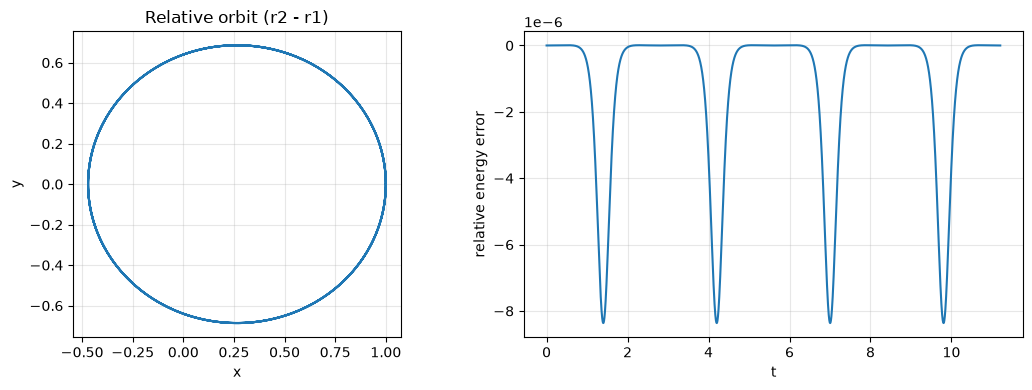

In [4]:
# Period check: apoapsis passages are local maxima of r(t)
peaks, _ = find_peaks(r_t)
period_sim = np.mean(np.diff(t_arr[peaks]))
err_T = abs(period_sim - T) / T
print(f'simulated period={period_sim:.6f}  analytic period={T:.6f}  error={err_T:.2e}')
assert err_T < 0.01, 'orbital period does not match analytic prediction'
print('PASS: orbital period matches.')

E_t = np.array([nb.energy(pos_t[i], vel_t[i], mass, G=G, softening=1e-6) for i in range(len(t_arr))])
L_t = np.array([nb.angular_momentum(pos_t[i], vel_t[i], mass) for i in range(len(t_arr))])
E_drift = (E_t.max() - E_t.min()) / abs(E_t.mean())
L_drift = (L_t.max() - L_t.min()) / abs(L_t.mean())
print(f'energy relative drift={E_drift:.2e}  angular momentum relative drift={L_drift:.2e}')
assert E_drift < 1e-4 and L_drift < 1e-6, 'conservation laws violated over the run'
print('PASS: energy and angular momentum conserved over 4 periods.')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(rel[:, 0], rel[:, 1])
axes[0].set_aspect('equal'); axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Relative orbit (r2 - r1)'); axes[0].grid(alpha=0.3)
axes[1].plot(t_arr, (E_t - E_t[0]) / abs(E_t[0]))
axes[1].set_xlabel('t'); axes[1].set_ylabel('relative energy error'); axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/kepler_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## Three-body: the Lagrange equilateral-triangle solution

`legacy/3_Body_Orbit_Phase_Space.ipynb`'s figure-eight choreography was
tried first as the second (genuinely 3-body) validation case, but it
involves repeated close encounters between bodies (minimum separation
`~0.0045` in these units) that are numerically stiff for a *fixed-step*
symplectic integrator: without either an adaptive/individual timestep
scheme or a softening length comparable to the encounter scale (which
then distorts the marginally-stable choreography itself, since it's only
an exact periodic solution of the *unsoftened* problem), the leapfrog
integration's energy blows up during the close passages. Both are outside
the scope of this simple engine, so this notebook uses a different,
numerically benign 3-body case instead: the **Lagrange equilateral
triangle** solution, in which three masses at the vertices of an
equilateral triangle each move on a circle about the common center of
mass, with angular velocity `Omega^2 = G*(m1+m2+m3)/s^3` -- independent of
the individual mass ratios, a clean closed-form result (Lagrange, 1772).
No close encounters, so it's also a fair test of `pairwise_accel` actually
summing contributions from *two* other bodies correctly (unlike the
two-body case above).

In [5]:
m = 1.0
s = 1.0  # triangle side length
mass3 = np.array([m, m, m])
Omega = np.sqrt(G * 3 * m / s**3)
r_tri = s / np.sqrt(3)         # centroid-to-vertex distance for equal masses
T3 = 2 * np.pi / Omega
print(f'Omega={Omega:.6f}  r={r_tri:.6f}  T={T3:.6f}')

thetas = np.array([0, 2 * np.pi / 3, 4 * np.pi / 3])
pos0_3 = r_tri * np.stack([np.cos(thetas), np.sin(thetas)], axis=1)
vel0_3 = Omega * r_tri * np.stack([-np.sin(thetas), np.cos(thetas)], axis=1)

Omega=1.732051  r=0.577350  T=3.627599


In [6]:
n_periods3 = 5
dt3 = T3 / 2000
n_steps3 = int(round(n_periods3 * T3 / dt3))
pos_t3, vel_t3 = nb.integrate(pos0_3, vel0_3, mass3, dt3, n_steps3, nb.pairwise_accel, G=G, softening=1e-6)
t_arr3 = np.arange(n_steps3 + 1) * dt3

radius = np.linalg.norm(pos_t3, axis=-1)
d01 = np.linalg.norm(pos_t3[:, 0] - pos_t3[:, 1], axis=-1)
d02 = np.linalg.norm(pos_t3[:, 0] - pos_t3[:, 2], axis=-1)
d12 = np.linalg.norm(pos_t3[:, 1] - pos_t3[:, 2], axis=-1)
side_lengths = np.stack([d01, d02, d12])

err_r = np.max(np.abs(radius - r_tri)) / r_tri
err_s = np.max(np.abs(side_lengths - s)) / s
print(f'max centroid-distance error={err_r:.2e}  max side-length error={err_s:.2e}')
assert err_r < 1e-3 and err_s < 1e-3, 'equilateral configuration not preserved'
print('PASS: the triangle stays equilateral and each body stays on its predicted circular orbit.')

max centroid-distance error=5.05e-06  max side-length error=5.04e-06
PASS: the triangle stays equilateral and each body stays on its predicted circular orbit.


energy relative drift=2.44e-11  angular momentum relative drift=1.38e-14
PASS: energy and angular momentum conserved over 5 periods.


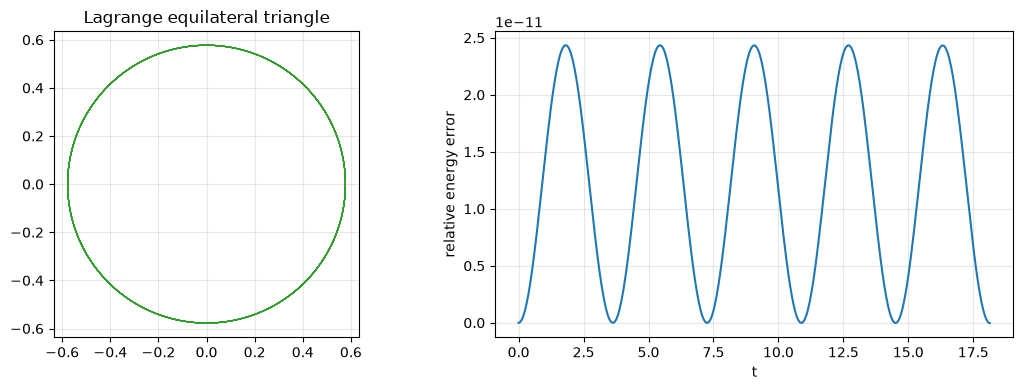

In [7]:
E_t3 = np.array([nb.energy(pos_t3[i], vel_t3[i], mass3, G=G, softening=1e-6) for i in range(0, len(t_arr3), 20)])
L_t3 = np.array([nb.angular_momentum(pos_t3[i], vel_t3[i], mass3) for i in range(0, len(t_arr3), 20)])
E_drift3 = (E_t3.max() - E_t3.min()) / abs(E_t3.mean())
L_drift3 = (L_t3.max() - L_t3.min()) / abs(L_t3.mean())
print(f'energy relative drift={E_drift3:.2e}  angular momentum relative drift={L_drift3:.2e}')
assert E_drift3 < 1e-6 and L_drift3 < 1e-6, 'conservation laws violated over the run'
print(f'PASS: energy and angular momentum conserved over {n_periods3} periods.')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for j in range(3):
    axes[0].plot(pos_t3[:, j, 0], pos_t3[:, j, 1], lw=0.8)
axes[0].set_aspect('equal'); axes[0].set_title('Lagrange equilateral triangle'); axes[0].grid(alpha=0.3)
axes[1].plot(t_arr3[::20], (E_t3 - E_t3[0]) / abs(E_t3[0]))
axes[1].set_xlabel('t'); axes[1].set_ylabel('relative energy error'); axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/lagrange_triangle_validation.png', dpi=150, bbox_inches='tight')
plt.show()